In [5]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


# zum import von py Dateien
from pathlib import Path
import sys

# Projekt-Root zum importieren von Helper
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Helper import Helper 

0.10024+/-0.00007
9.976+/-0.007


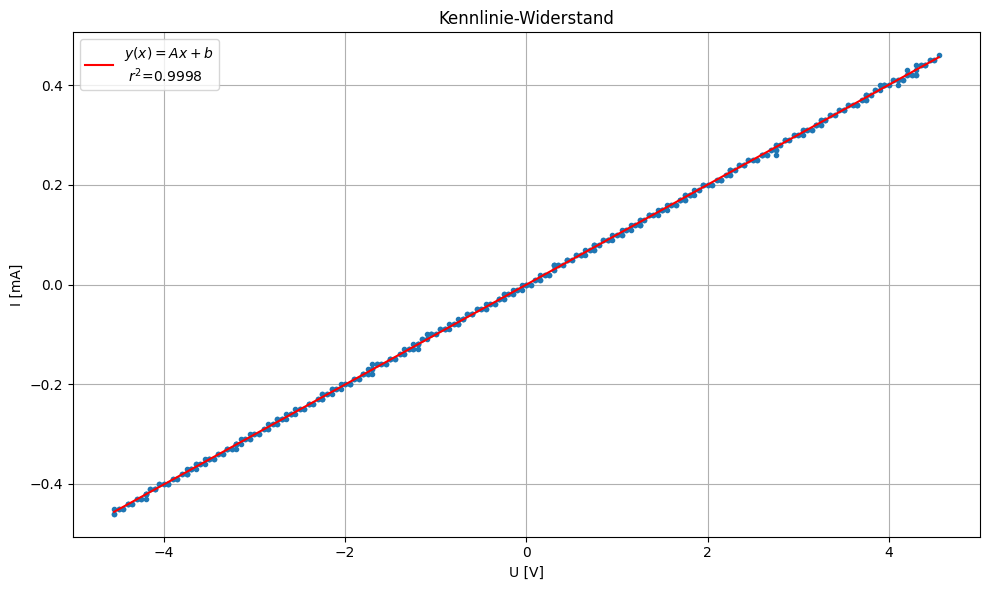

(9.3+/-1.5)e-06
2.053+/-0.032


/tmp/ipykernel_1412/1957689845.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


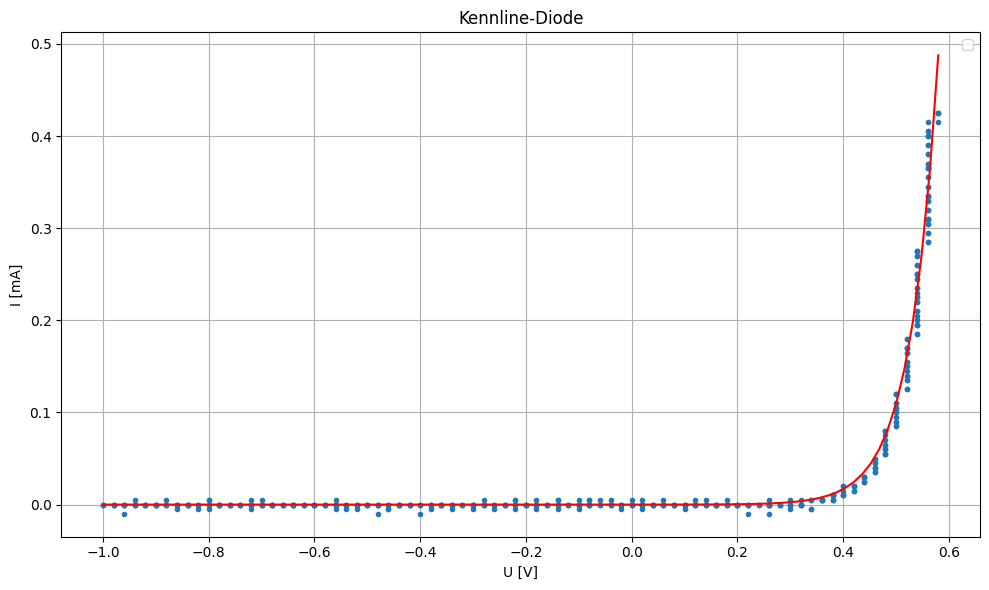

In [55]:
# fits


Data = pd.read_csv("Widerstand.csv", sep=',', decimal='.')   # read csv für den Graphen


U = Data["channelA"].to_numpy()    # V Dehnung Data

I = Data["channelB"].to_numpy()    # mA Spannung Data


#linfit

popt_1, pcov_1 = curve_fit(Helper.linfit, U, I, p0=[1, 1])

a_opt, b_opt = popt_1
x_model_1 = np.linspace(min(U), max(U), 100)
y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
perr_1 = np.sqrt(np.diag(pcov_1))

A_1 = ufloat(a_opt,perr_1[0])

print(A_1)
print(1/A_1)
r2_1 = Helper.r2_curve_fit(popt_1, U, I, Helper.linfit)






# plot
plt.figure(figsize=(10, 6))
plt.plot(U, I,".")
plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2_1:.4f}")
# plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.ylabel(r"I [mA]")
plt.xlabel(r"U [V]")
plt.legend()
plt.title("Kennlinie-Widerstand")
plt.tight_layout()
plt.grid()
plt.show()
# other fit


U_T = 0.026 #V

def fit(x,A,B):
    return A*(np.exp(x/(B*U_T))-1)



Data = pd.read_csv("diode1.csv", sep=',', decimal='.')   # read csv für den Graphen


U_1 = Data["channelA(V)"].to_numpy()    # Dehnung Data

I_1 = Data["channelB(uA)"].to_numpy()/1000    # Spannung Data


#linfit

popt_2, pcov_2 = curve_fit(fit, U_1, I_1, p0=[1, 1])

a_opt, b_opt = popt_2
x_model_2 = np.linspace(min(U_1), max(U_1), 100)
y_model_2 = fit(x_model_2, a_opt, b_opt)
perr_2 = np.sqrt(np.diag(pcov_2))

A_1 = ufloat(a_opt,perr_2[0])
B_1 = ufloat(b_opt,perr_2[1])

print(A_1)
print(B_1)
# r2_2 = Helper.r2_curve_fit(popt_1, U_1, I_1, fit)



# plot
plt.figure(figsize=(10, 6))
plt.plot(U_1, I_1,".")
plt.plot(x_model_2, y_model_2, color='r')
# plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.ylabel(r"I [mA]")
plt.xlabel(r"U [V]")
plt.legend()
plt.title("Kennline-Diode")
plt.tight_layout()
plt.grid()
plt.show()



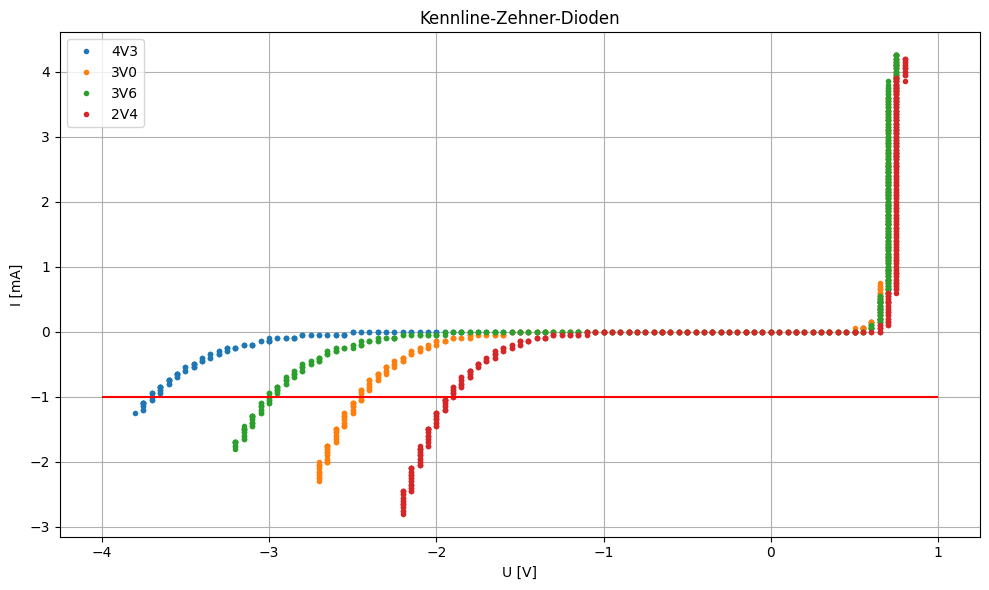

In [49]:
Data = pd.read_csv("10-dioden.csv", sep=',', decimal='.')   # read csv für den Graphen


U_1 = Data["channelA(1)"].to_numpy()    # V Dehnung Data
U_2 = Data["channelA(2)"].to_numpy()    # V Dehnung Data
U_3 = Data["channelA(3)"].to_numpy()    # V Dehnung Data
U_4 = Data["channelA(4)"].to_numpy()    # V Dehnung Data

I_1 = Data["channelB(1)"].to_numpy()    # mA Spannung Data
I_2 = Data["channelB(2)"].to_numpy()    # mA Spannung Data
I_3 = Data["channelB(3)"].to_numpy()    # mA Spannung Data
I_4 = Data["channelB(4)"].to_numpy()    # mA Spannung Data


# plot
plt.figure(figsize=(10, 6))
plt.plot(U_1, I_1,".", label="4V3")
plt.plot(U_2, I_2,".", label="3V0")
plt.plot(U_3, I_3,".", label="3V6")
plt.plot(U_4, I_4,".", label="2V4")
plt.hlines(-1,-4,1, colors="r")
# plt.plot(x_model_2, y_model_2, color='r')
# plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.ylabel(r"I [mA]")
plt.xlabel(r"U [V]")
plt.legend()
plt.title("Kennline-Zehner-Dioden")
plt.tight_layout()
plt.grid()
plt.show()

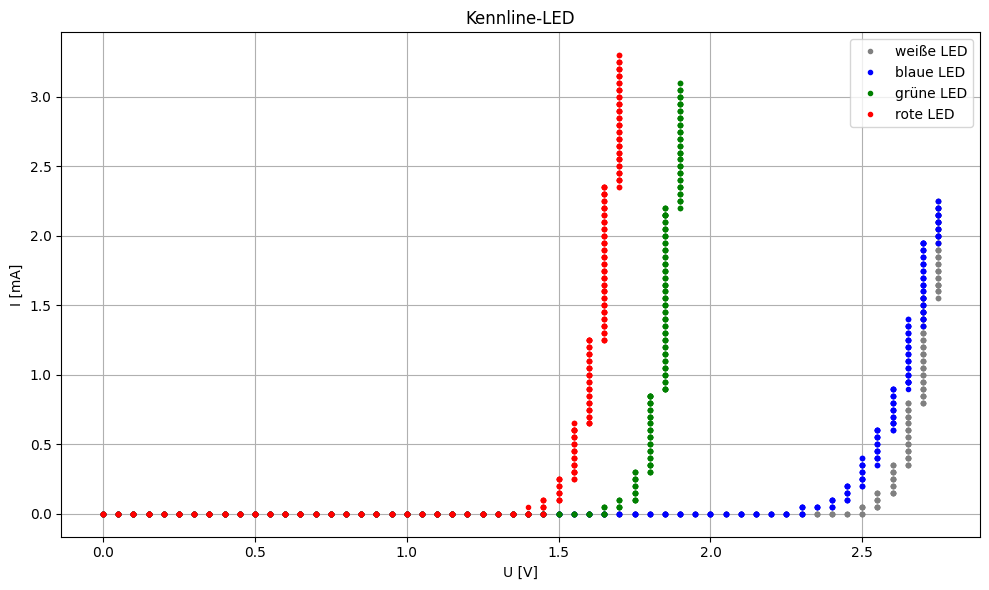

In [56]:
Data = pd.read_csv("LED.csv", sep=',', decimal='.')   # read csv für den Graphen


U_1 = Data["channelA(1)"].to_numpy()    # V Dehnung Data
U_2 = Data["channelA(2)"].to_numpy()    # V Dehnung Data
U_3 = Data["channelA(3)"].to_numpy()    # V Dehnung Data
U_4 = Data["channelA(4)"].to_numpy()    # V Dehnung Data

I_1 = Data["channelB(1)"].to_numpy()    # mA Spannung Data
I_2 = Data["channelB(2)"].to_numpy()    # mA Spannung Data
I_3 = Data["channelB(3)"].to_numpy()    # mA Spannung Data
I_4 = Data["channelB(4)"].to_numpy()    # mA Spannung Data


# plot
plt.figure(figsize=(10, 6))
plt.plot(U_1, I_1,".",color="grey", label="weiße LED")
plt.plot(U_2, I_2,".",color="b", label="blaue LED")
plt.plot(U_3, I_3,".",color="g", label="grüne LED")
plt.plot(U_4, I_4,".",color="r", label="rote LED")
# plt.hlines(-1,-4,1, colors="r")
# plt.plot(x_model_2, y_model_2, color='r')
# plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.ylabel(r"I [mA]")
plt.xlabel(r"U [V]")
plt.legend()
plt.title("Kennline-LED")
plt.tight_layout()
plt.grid()
plt.show()

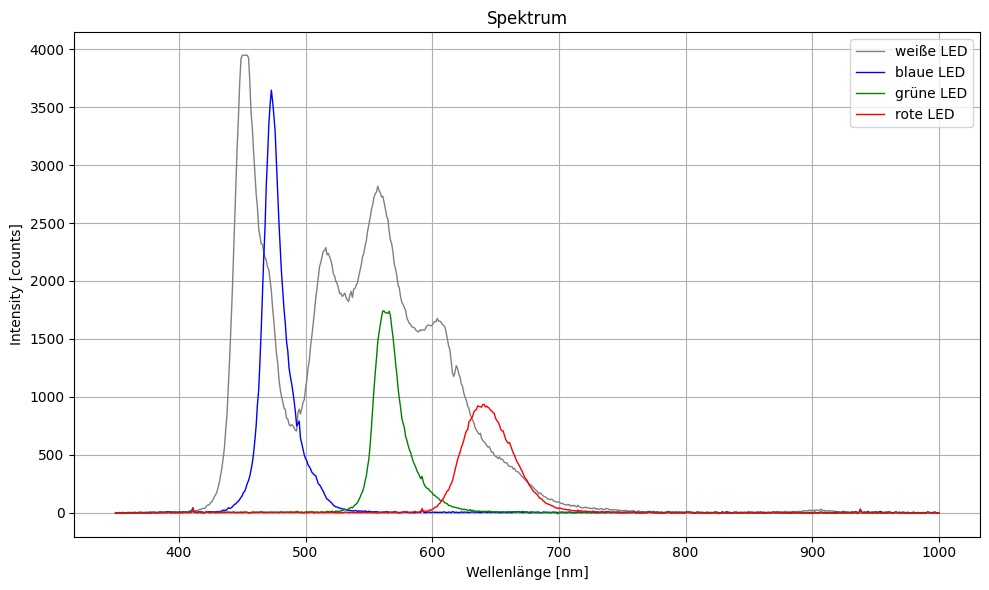

In [58]:
Data = pd.read_csv("spek.csv", sep=',', decimal='.')   # read csv für den Graphen


spek = Data["spek"].to_numpy()

w = Data["w"].to_numpy()    # V Dehnung Data
b = Data["b"].to_numpy()    # V Dehnung Data
g = Data["g"].to_numpy()    # V Dehnung Data
r = Data["r"].to_numpy()    # V Dehnung Data


plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(spek, w, '-', color="grey", linewidth=1, label="weiße LED")
plt.plot(spek, b, '-', color="b", linewidth=1, label="blaue LED")
plt.plot(spek, g, '-', color="g", linewidth=1, label="grüne LED")
plt.plot(spek, r, '-', color="r", linewidth=1, label="rote LED")
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(, N_Na, '-', linewidth=1, label="Na-22")
plt.xlabel("Wellenlänge [nm]")
plt.ylabel("Intensity [counts]")
plt.title("Spektrum")
plt.grid()
plt.legend()
plt.tight_layout()

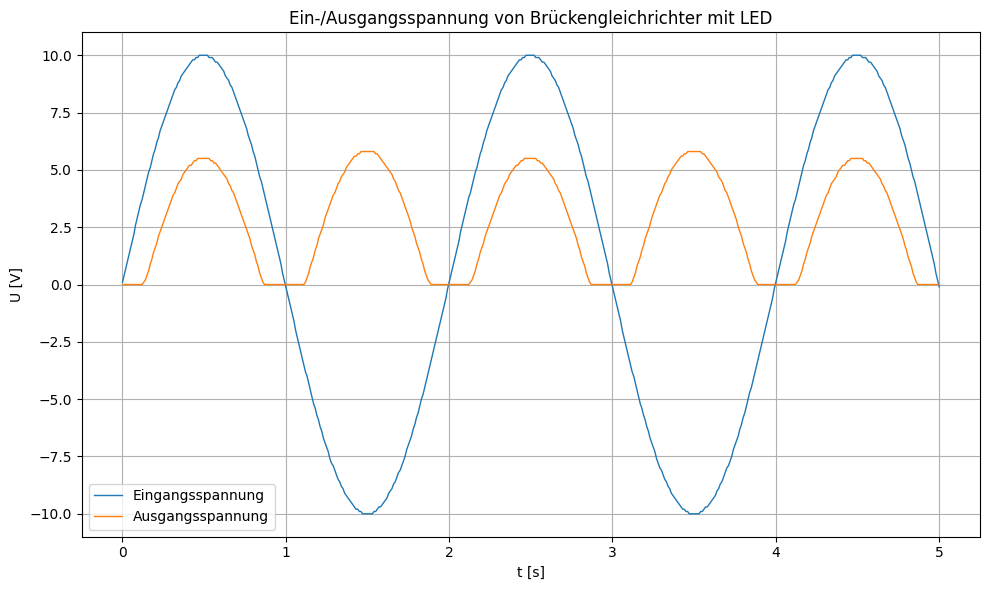

In [59]:
Data = pd.read_csv("LED-osz.csv", sep=',', decimal='.')   # read csv für den Graphen


t = Data["time (ms)"].to_numpy()/1000

U1 = Data["channelA(V)"].to_numpy()    # V Dehnung Data
U2 = Data["channelB(V)"].to_numpy()    # V Dehnung Data


plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(t, U1, '-', linewidth=1, label="Eingangsspannung")
plt.plot(t, U2, '-', linewidth=1, label="Ausgangsspannung")
# plt.plot(spek, g, '-', linewidth=1, label="Data")
# plt.plot(spek, r, '-', linewidth=1, label="Data")
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(, N_Na, '-', linewidth=1, label="Na-22")
plt.xlabel("t [s]")
plt.ylabel("U [V]")
plt.title("Ein-/Ausgangsspannung von Brückengleichrichter mit LED")
plt.grid()
plt.legend()
plt.tight_layout()

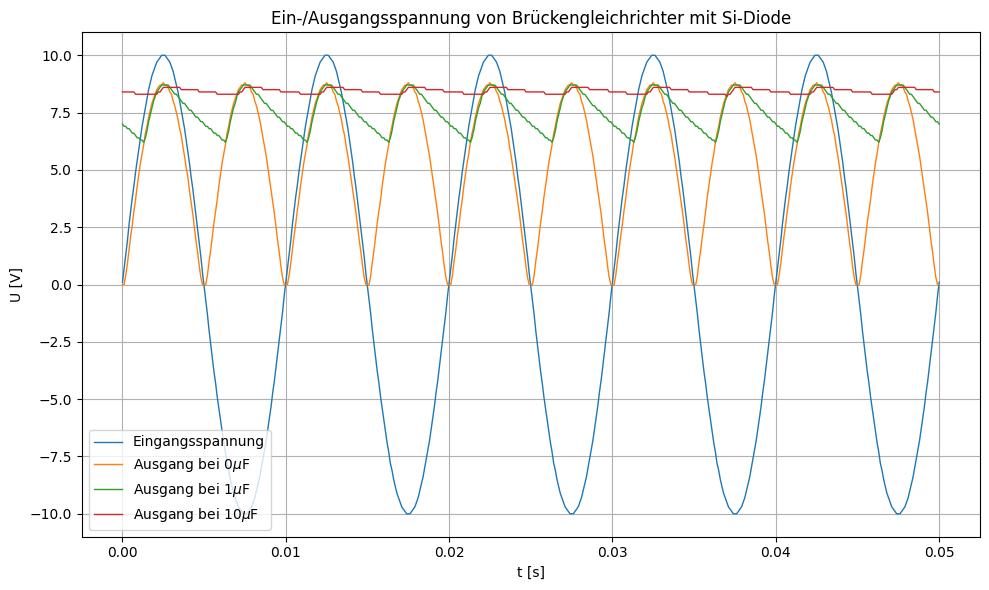

In [61]:
Data = pd.read_csv("glatt.csv", sep=',', decimal='.')   # read csv für den Graphen


t = Data["time (ms)"].to_numpy()/1000

U1 = Data["channelA(1)"].to_numpy()    # V Dehnung Data
U2 = Data["channelB(1)"].to_numpy()    # V Dehnung Data
U3 = Data["channelB(2)"].to_numpy()    # V Dehnung Data
U4 = Data["channelB(3)"].to_numpy()    # V Dehnung Data


plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(t, U1, '-', linewidth=1, label="Eingangsspannung")
plt.plot(t, U2, '-', linewidth=1, label=r"Ausgang bei 0$\mu$F")
plt.plot(t, U3, '-', linewidth=1, label=r"Ausgang bei 1$\mu$F")
plt.plot(t, U4, '-', linewidth=1, label=r"Ausgang bei 10$\mu$F")
# plt.plot(spek, g, '-', linewidth=1, label="Data")
# plt.plot(spek, r, '-', linewidth=1, label="Data")
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(, N_Na, '-', linewidth=1, label="Na-22")
plt.xlabel("t [s]")
plt.ylabel("U [V]")
plt.title("Ein-/Ausgangsspannung von Brückengleichrichter mit Si-Diode")
plt.grid()
plt.legend()
plt.tight_layout()

2.814+/-0.010
0.3554+/-0.0012


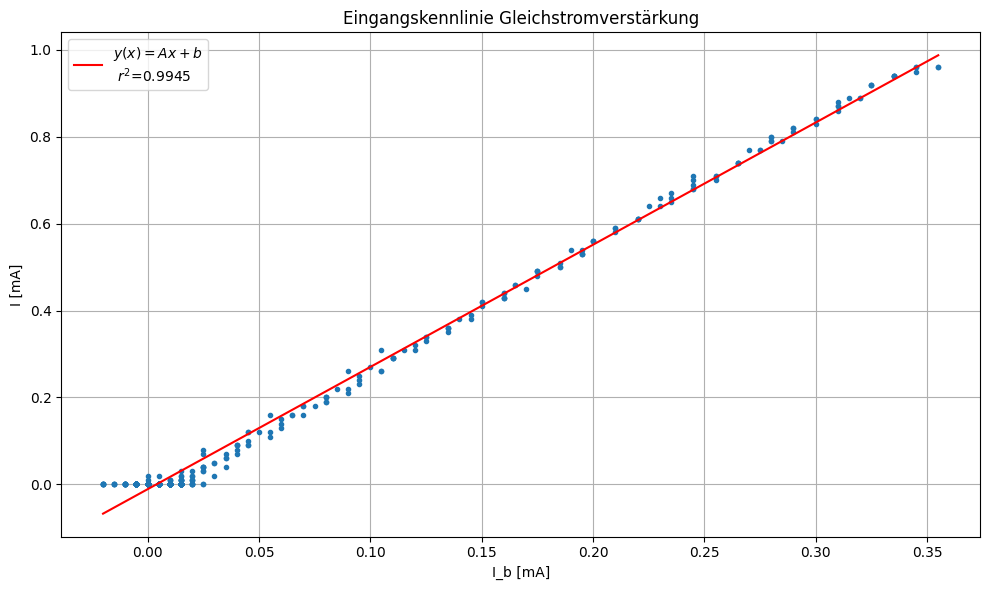

In [66]:
# fits


Data = pd.read_csv("linken.csv", sep=',', decimal='.')   # read csv für den Graphen


U = Data["channelA(V)"].to_numpy()    # V Dehnung Data

I = Data["channelB(mA)"].to_numpy()    # mA Spannung Data

I_b = U/100
#linfit

popt_1, pcov_1 = curve_fit(Helper.linfit, U, I, p0=[1, 1])

a_opt, b_opt = popt_1
x_model_1 = np.linspace(min(U), max(U), 100)
y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
perr_1 = np.sqrt(np.diag(pcov_1))

A_1 = ufloat(a_opt,perr_1[0])

print(A_1)
print(1/A_1)
r2_1 = Helper.r2_curve_fit(popt_1, U, I, Helper.linfit)






# plot
plt.figure(figsize=(10, 6))
plt.plot(U, I,".")
plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2_1:.4f}")
# plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.ylabel(r"I [mA]")
plt.xlabel(r"I_b [mA]")
plt.legend()
plt.title("Eingangskennlinie Gleichstromverstärkung")
plt.tight_layout()
plt.grid()
plt.show()

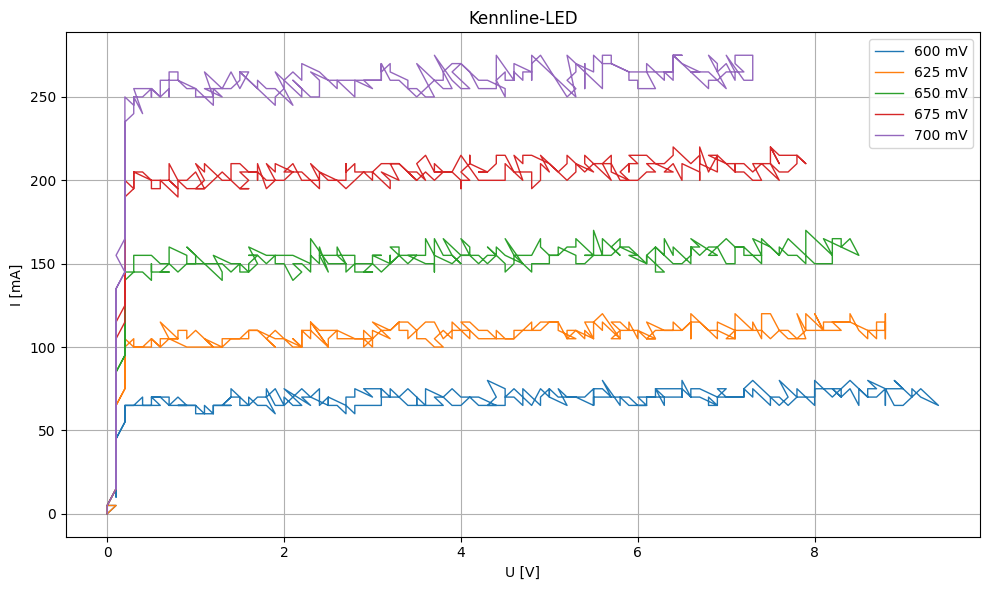

In [ ]:
Data = pd.read_csv("kennfeld.csv", sep=',', decimal='.')   # read csv für den Graphen


U_1 = Data["channelA(1)"].to_numpy()    # V Dehnung Data
U_2 = Data["channelA(2)"].to_numpy()    # V Dehnung Data
U_3 = Data["channelA(3)"].to_numpy()    # V Dehnung Data
U_4 = Data["channelA(4)"].to_numpy()    # V Dehnung Data
U_5 = Data["channelA(5)"].to_numpy()    # V Dehnung Data

I_1 = Data["channelB(1)"].to_numpy()    # uA Spannung Data
I_2 = Data["channelB(2)"].to_numpy()    # uA Spannung Data
I_3 = Data["channelB(3)"].to_numpy()    # uA Spannung Data
I_4 = Data["channelB(4)"].to_numpy()    # uA Spannung Data
I_5 = Data["channelB(5)"].to_numpy()    # uA Spannung Data


# plot
plt.figure(figsize=(10, 6))
plt.plot(U_1, I_1, '-', linewidth=1, label="600 mV")
plt.plot(U_2, I_2, '-', linewidth=1, label="625 mV")
plt.plot(U_3, I_3, '-', linewidth=1, label="650 mV")
plt.plot(U_4, I_4, '-', linewidth=1, label="675 mV")
plt.plot(U_5, I_5, '-', linewidth=1, label="700 mV")
# plt.hlines(-1,-4,1, colors="r")
# plt.plot(x_model_2, y_model_2, color='r')
# plt.errorbar(H_4, Pro, fmt='o', yerr= Pro_uu, capsize=3, markersize=4, label="errorbars")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.ylabel(r"I [uA]")
plt.xlabel(r"U [V]")
plt.legend()
plt.title("gedanken")
plt.tight_layout()
plt.grid()
plt.show()

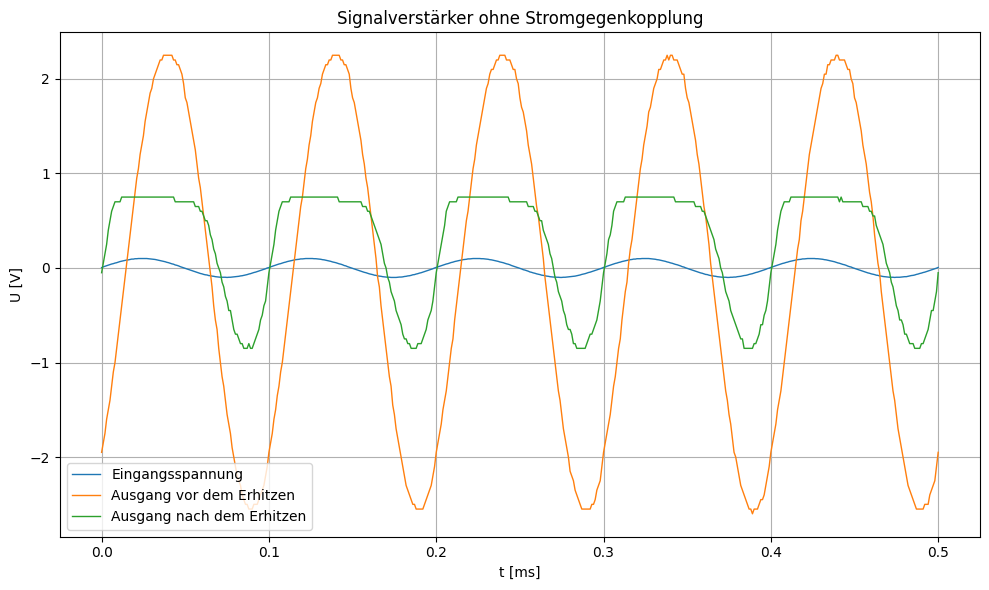

In [65]:
U_c_1 = ufloat(2.685,0.050) # V
U_c_2 = ufloat(0.675,0.1) # V



Data = pd.read_csv("temp1.csv", sep=',', decimal='.')   # read csv für den Graphen


t = Data["time (us)"].to_numpy()/1000 #ms

U1 = Data["channelA(1)"].to_numpy()    # V Dehnung Data
U2 = Data["channelB(1)"].to_numpy()    # V Dehnung Data
U3 = Data["channelB(2)"].to_numpy()    # V Dehnung Data
# U4 = Data["channelB(3)"].to_numpy()    # V Dehnung Data


plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(t, U1, '-', linewidth=1, label="Eingangsspannung")
plt.plot(t, U2, '-', linewidth=1, label="Ausgang vor dem Erhitzen")
plt.plot(t, U3, '-', linewidth=1, label="Ausgang nach dem Erhitzen")
# plt.plot(t, U4, '-', linewidth=1, label="Data")
# plt.plot(spek, g, '-', linewidth=1, label="Data")
# plt.plot(spek, r, '-', linewidth=1, label="Data")
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(, N_Na, '-', linewidth=1, label="Na-22")
plt.xlabel("t [ms]")
plt.ylabel("U [V]")
plt.title("Signalverstärker ohne Stromgegenkopplung")
plt.grid()
plt.legend()
plt.tight_layout()

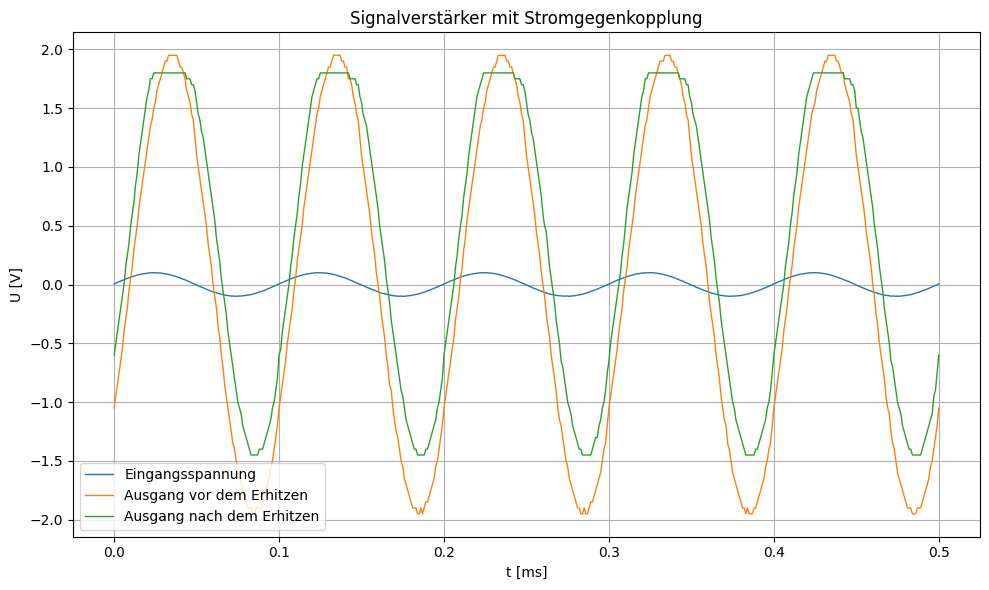

In [64]:
U_c_1 = ufloat(3.68,0.050) # V
U_c_2 = ufloat(1.720,0.1) # V



Data = pd.read_csv("temp2.csv", sep=',', decimal='.')   # read csv für den Graphen


t = Data["time (us)"].to_numpy()/1000 #ms

U1 = Data["channelA(1)"].to_numpy()    # V Dehnung Data
U2 = Data["channelB(1)"].to_numpy()    # V Dehnung Data
U3 = Data["channelB(2)"].to_numpy()    # V Dehnung Data
# U4 = Data["channelB(3)"].to_numpy()    # V Dehnung Data


plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(t, U1, '-', linewidth=1, label="Eingangsspannung")
plt.plot(t, U3, '-', linewidth=1, label="Ausgang vor dem Erhitzen")
plt.plot(t, U2, '-', linewidth=1, label="Ausgang nach dem Erhitzen")
# plt.plot(t, U4, '-', linewidth=1, label="Data")
# plt.plot(spek, g, '-', linewidth=1, label="Data")
# plt.plot(spek, r, '-', linewidth=1, label="Data")
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(, N_Na, '-', linewidth=1, label="Na-22")
plt.xlabel("t [ms]")
plt.ylabel("U [V]")
plt.title("Signalverstärker mit Stromgegenkopplung")
plt.grid()
plt.legend()
plt.tight_layout()